## Fuente de los datos

Dataset diario de demanda, generación y precios eléctricos de España (2014-2018), 
recopilado de ESIOS, la plataforma de REE (Red Eléctrica Española), el operador 
del sistema eléctrico español. El dataset mantiene el formato original de la fuente, 
por lo que las columnas `geoid`/`geoname` vienen vacías en la mayoría de las filas 
(esto es intencional, según la documentación del dataset, para facilitar agregar 
nuevos datos con el mismo formato).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('spain_energy_market.csv')
df.head(10)

,datetime,id,name,geoid,geoname,value
0,2014-01-01 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,25.280833
1,2014-01-02 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,39.924167
2,2014-01-03 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.992083
3,2014-01-04 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.091667
4,2014-01-05 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,13.587500
5,2014-01-06 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,47.885417
6,2014-01-07 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,41.207500
7,2014-01-08 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,49.022083
8,2014-01-09 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,56.202917
9,2014-01-10 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,50.277083


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  40212 non-null  str    
 1   id        40212 non-null  int64  
 2   name      34734 non-null  str    
 3   geoid     10956 non-null  float64
 4   geoname   10956 non-null  str    
 5   value     40212 non-null  float64
dtypes: float64(2), int64(1), str(3)
memory usage: 1.8 MB


In [3]:
df['name'].value_counts(dropna=False)

name
NaN                                                                       5478
Precio mercado SPOT Diario ESP                                            1826
Precio mercado SPOT Diario FRA                                            1826
Precio mercado SPOT Diario POR                                            1826
Energía asignada en Mercado SPOT Diario España                            1826
Energía asignada en Mercado SPOT Diario Francia                           1826
Generación programada PBF Gas Natural Cogeneración                        1826
Generación programada PBF UGH + no UGH                                    1826
Generación programada PBF Solar fotovoltaica                              1826
Demanda real                                                              1825
Demanda programada PBF total                                              1825
Generación programada PBF total                                           1825
Generación programada PBF Eólica               

In [4]:
precio_es = df[df['name'] == 'Precio mercado SPOT Diario ESP'][['datetime', 'value']]
precio_es = precio_es.rename(columns={'value': 'precio_eur_mwh'})

demanda_es = df[df['name'] == 'Demanda real'][['datetime', 'value']]
demanda_es = demanda_es.rename(columns={'value': 'demanda_mw'})

generacion_es = df[df['name'] == 'Generación programada PBF total'][['datetime', 'value']]
generacion_es = generacion_es.rename(columns={'value': 'generacion_mwh'})


print(precio_es.shape)
print(demanda_es.shape)
print(generacion_es.shape)

precio_es.head()

(1826, 2)
(1825, 2)
(1825, 2)


,datetime,precio_eur_mwh
0,2014-01-01 23:00:00,25.280833
1,2014-01-02 23:00:00,39.924167
2,2014-01-03 23:00:00,4.992083
3,2014-01-04 23:00:00,4.091667
4,2014-01-05 23:00:00,13.587500


In [5]:
demanda_es.head()

,datetime,demanda_mw
20169,2014-01-01 23:00:00,28191.597222
20170,2014-01-02 23:00:00,28465.180556
20171,2014-01-03 23:00:00,26860.493056
20172,2014-01-04 23:00:00,25333.597222
20173,2014-01-05 23:00:00,23905.541667


In [6]:
generacion_es.head()

,datetime,generacion_mwh
23819,2014-01-01 23:00:00,642771.8
23820,2014-01-02 23:00:00,658078.5
23821,2014-01-03 23:00:00,680564.6
23822,2014-01-04 23:00:00,644494.7
23823,2014-01-05 23:00:00,598661.4


In [7]:
precio_es['datetime'] = pd.to_datetime(precio_es['datetime'])
demanda_es['datetime'] = pd.to_datetime(demanda_es['datetime'])
generacion_es['datetime'] = pd.to_datetime(generacion_es['datetime'])


serie_es = pd.merge(precio_es, demanda_es, on='datetime', how='outer')
serie_es = pd.merge(serie_es, generacion_es, on='datetime', how='outer')
serie_es = serie_es.sort_values('datetime')

print(serie_es.shape)
print(serie_es.isnull().sum())
serie_es.head()

(1826, 4)
datetime          0
precio_eur_mwh    0
demanda_mw        1
generacion_mwh    1
dtype: int64


,datetime,precio_eur_mwh,demanda_mw,generacion_mwh
0,2014-01-01 23:00:00,25.280833,28191.597222,642771.8
1,2014-01-02 23:00:00,39.924167,28465.180556,658078.5
2,2014-01-03 23:00:00,4.992083,26860.493056,680564.6
3,2014-01-04 23:00:00,4.091667,25333.597222,644494.7
4,2014-01-05 23:00:00,13.587500,23905.541667,598661.4


In [8]:
serie_es[serie_es['demanda_mw'].isnull()]


,datetime,precio_eur_mwh,demanda_mw,generacion_mwh
1825,2018-12-31 23:00:00,63.454583,NaN,NaN


In [9]:
serie_es[serie_es['generacion_mwh'].isnull()]


,datetime,precio_eur_mwh,demanda_mw,generacion_mwh
1825,2018-12-31 23:00:00,63.454583,NaN,NaN


### Investigación de precios anormalmente bajos

Antes de dar el dataset por limpio, revisamos si había valores extremos sospechosos 
en el precio.

In [10]:
serie_es.sort_values('precio_eur_mwh').head(10)

,datetime,precio_eur_mwh,demanda_mw,generacion_mwh
38,2014-02-08 23:00:00,0.477917,26391.076389,643262.6
59,2014-03-01 23:00:00,0.778750,25153.986111,627516.3
37,2014-02-07 23:00:00,1.100000,28287.645833,713173.4
60,2014-03-02 23:00:00,1.268750,30109.993056,735092.9
58,2014-02-28 23:00:00,2.280417,28182.451389,650949.8
61,2014-03-03 23:00:00,2.840833,31147.451389,727816.8
43,2014-02-13 23:00:00,3.124583,30560.840278,741236.5
39,2014-02-09 23:00:00,3.183333,31329.951389,779833.9
36,2014-02-06 23:00:00,3.195000,31381.583333,765204.1
3,2014-01-04 23:00:00,4.091667,25333.597222,644494.7


In [11]:
demanda_promedio_general = serie_es['demanda_mw'].mean()
dias_precio_bajo = serie_es.sort_values('precio_eur_mwh').head(10)

print("Demanda promedio general:", demanda_promedio_general)
print("\nDemanda en los 10 días de precio más bajo:")
print(dias_precio_bajo['demanda_mw'])

Demanda promedio general: 28506.322147084902

Demanda en los 10 días de precio más bajo:
38    26391.076389
59    25153.986111
37    28287.645833
60    30109.993056
58    28182.451389
61    31147.451389
43    30560.840278
39    31329.951389
36    31381.583333
3     25333.597222
Name: demanda_mw, dtype: float64


In [12]:
generacion_promedio_general = serie_es['generacion_mwh'].mean()
dias_precio_bajo = serie_es.sort_values('precio_eur_mwh').head(10)

print("Generación promedio general:", generacion_promedio_general)
print("\nGeneración en los 10 días de precio más bajo:")
print(dias_precio_bajo['generacion_mwh'])

Generación promedio general: 648991.317369863

Generación en los 10 días de precio más bajo:
38    643262.6
59    627516.3
37    713173.4
60    735092.9
58    650949.8
61    727816.8
43    741236.5
39    779833.9
36    765204.1
3     644494.7
Name: generacion_mwh, dtype: float64


Los precios más bajos de toda la serie se concentran en inicios de 2014. Al comparar 
la demanda de esos días contra el promedio general (28,505 MW), no se observó un 
patrón claro de demanda baja — varios días tuvieron demanda incluso por encima del 
promedio, descartando la demanda como causa principal.

Al revisar la generación total de esos mismos días contra su propio promedio general 
(648,924 MWh), sí aparece un patrón consistente: 7 de los 10 días de precio más bajo 
tuvieron generación por encima del promedio (hasta 130,000 MWh más en algunos casos). 
Esto es evidencia de **sobreoferta**: se generó más electricidad de lo habitual sin 
que la demanda estuviera especialmente alta, una combinación que reduce el precio de 
mercado. El dataset no permite identificar qué tecnología específica (eólica, solar, 
hidráulica, etc.) impulsó esa mayor generación, pero el patrón general de sobreoferta 
queda confirmado con los datos disponibles.

### Completando el dato faltante del último día

`demanda_mw` tiene un único valor faltante, correspondiente al 31/12/2018 — el último 
día de toda la serie. Como no existe un día posterior del cual interpolar, no aplica 
una interpolación real (que necesita un punto antes *y* después). En su lugar, usamos 
`.ffill()` ("forward fill"), que simplemente repite el último valor conocido (30/12/2018) 
para completar el hueco — una descripción más honesta de lo que ocurre en este caso 
puntual que llamarlo "interpolación".

In [13]:
serie_es = serie_es.set_index('datetime')
serie_es['demanda_mw'] = serie_es['demanda_mw'].ffill()
serie_es['generacion_mwh'] = serie_es['generacion_mwh'].ffill()


print(serie_es.isnull().sum())
serie_es.tail()

precio_eur_mwh    0
demanda_mw        0
generacion_mwh    0
dtype: int64


,precio_eur_mwh,demanda_mw,generacion_mwh
datetime,,,
2018-12-27 23:00:00,63.785417,28624.194444,589771.5
2018-12-28 23:00:00,57.048333,26632.840278,543353.5
2018-12-29 23:00:00,58.493750,25255.055556,510049.1
2018-12-30 23:00:00,61.795000,25908.576389,526930.6
2018-12-31 23:00:00,63.454583,25908.576389,526930.6


In [14]:
serie_es['dia_semana'] = serie_es.index.day_name()
serie_es['es_finde'] = serie_es.index.dayofweek >= 5

serie_es.head()

,precio_eur_mwh,demanda_mw,generacion_mwh,dia_semana,es_finde
datetime,,,,,
2014-01-01 23:00:00,25.280833,28191.597222,642771.8,Wednesday,False
2014-01-02 23:00:00,39.924167,28465.180556,658078.5,Thursday,False
2014-01-03 23:00:00,4.992083,26860.493056,680564.6,Friday,False
2014-01-04 23:00:00,4.091667,25333.597222,644494.7,Saturday,True
2014-01-05 23:00:00,13.587500,23905.541667,598661.4,Sunday,True


### Análisis simple: distribución del precio spot diario

Un histograma agrupa los valores en rangos y muestra cuántos días caen en cada uno — 
permite ver si el precio está concentrado, disperso, o sesgado hacia algún extremo.

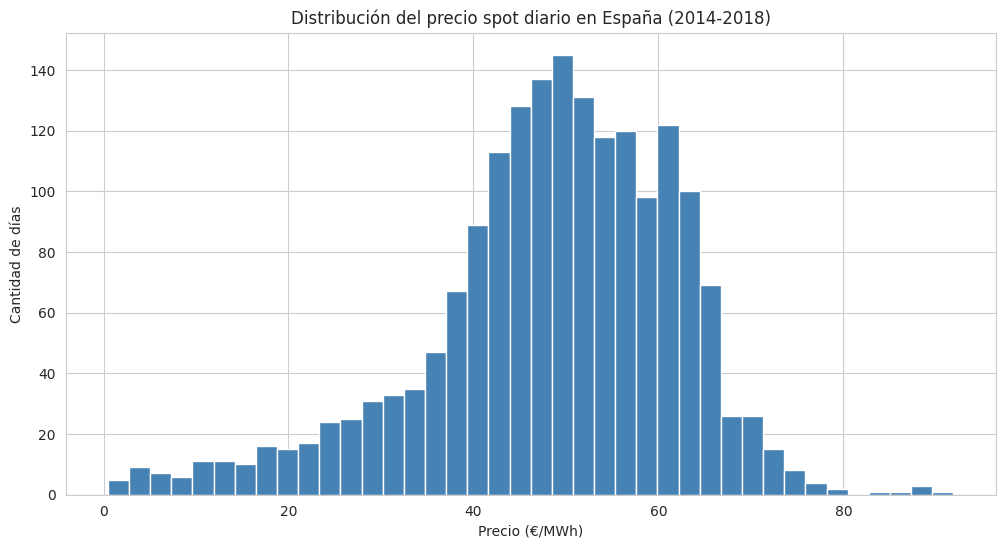

In [15]:
plt.hist(serie_es['precio_eur_mwh'], bins=40, color='steelblue', edgecolor='white')
plt.title('Distribución del precio spot diario en España (2014-2018)')
plt.xlabel('Precio (€/MWh)')
plt.ylabel('Cantidad de días')
plt.show()

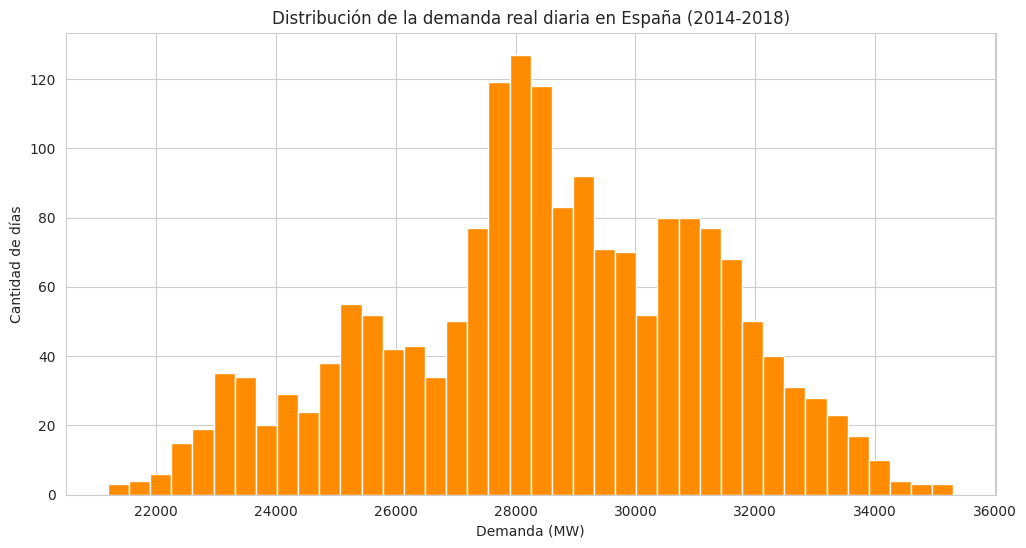

In [16]:
plt.hist(serie_es['demanda_mw'], bins=40, color='darkorange', edgecolor='white')
plt.title('Distribución de la demanda real diaria en España (2014-2018)')
plt.xlabel('Demanda (MW)')
plt.ylabel('Cantidad de días')
plt.show()

Mini-reporte de estos dos histogramas:

Hallazgo: el precio tiene sesgo hacia valores bajos (por el episodio de sobreoferta de 2014), mientras que la demanda es notablemente más simétrica y estable. Esta diferencia de forma es coherente con la correlación débil (0.31) encontrada entre ambas variables — confirma con otra evidencia que el precio no depende principalmente de la demanda.

### Correlación entre precio y demanda

Calculamos la correlación entre `precio_eur_mwh` y `demanda_mw`. Este 
número va de -1 a 1: cerca de 0 indica que no hay relación lineal aparente entre 
ambas variables; cerca de 1 indica que suben y bajan juntas; cerca de -1 indica que 
una sube cuando la otra baja.

In [17]:
correlacion = serie_es['precio_eur_mwh'].corr(serie_es['demanda_mw'])
print(f"Correlación entre precio y demanda: {correlacion:.2f}")

Correlación entre precio y demanda: 0.31


La correlación es 0.31 — positiva pero débil-moderada, consistente con la diferencia moderada observada entre día de semana/fin de semana, y con los episodios de precio muy bajo detectados independientemente del nivel de demanda.

### Correlación entre precio y generación total

Para confirmar si la sobreoferta observada en esos 10 días se sostiene en toda la 
serie (no solo en esos casos puntuales), calculamos la correlación entre 
`precio_eur_mwh` y `generacion_mwh`, y la visualizamos con un scatterplot. Si la 
sobreoferta explica de forma consistente los precios bajos, esperaríamos una 
correlación **negativa**: a mayor generación, menor precio.

In [18]:
correlacion_gen = serie_es['precio_eur_mwh'].corr(serie_es['generacion_mwh'])
print(f"Correlación entre precio y generación: {correlacion_gen:.2f}")

Correlación entre precio y generación: 0.12


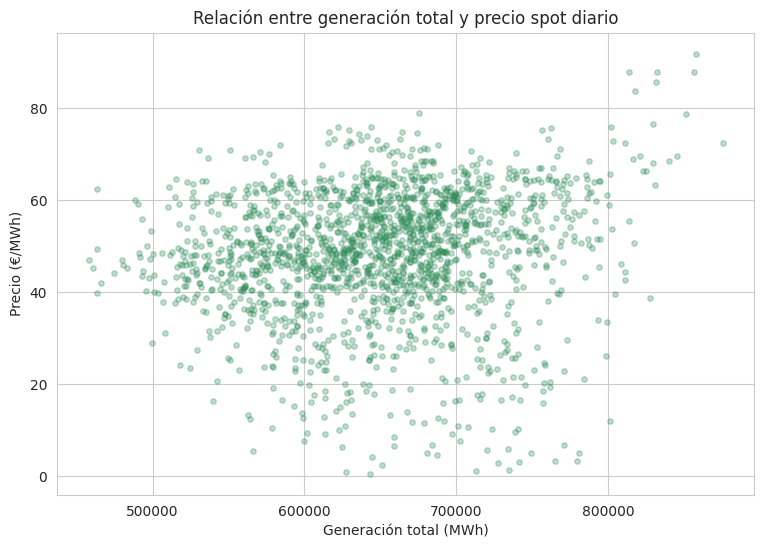

In [19]:
plt.figure(figsize=(9, 6))
plt.scatter(serie_es['generacion_mwh'], serie_es['precio_eur_mwh'], alpha=0.3, s=15, color='seagreen')
plt.xlabel('Generación total (MWh)')
plt.ylabel('Precio (€/MWh)')
plt.title('Relación entre generación total y precio spot diario')
plt.show()

Mini-reporte de este hallazgo:

Situación: calculamos la correlación entre precio y generación total, y la visualizamos con un scatterplot, para confirmar si el patrón de sobreoferta observado en los 10 días de precio más bajo se sostiene en toda la serie.
Hallazgo: la correlación entre precio y generación total es de apenas 0.12 — prácticamente nula, mucho más débil de lo que la hipótesis de sobreoferta haría esperar (se esperaba algo negativo y notorio). Esto significa que, mirando las 1,826 filas completas, la generación total por sí sola no explica de forma consistente las subas y bajas del precio.

### Distribución segmentada: precio según día de semana o fin de semana

Comparamos la distribución del precio spot diario entre días laborales y fines de 
semana, usando un boxplot (línea del medio = mediana, caja = 50% central de los 
datos, puntos sueltos = outliers de ese grupo).

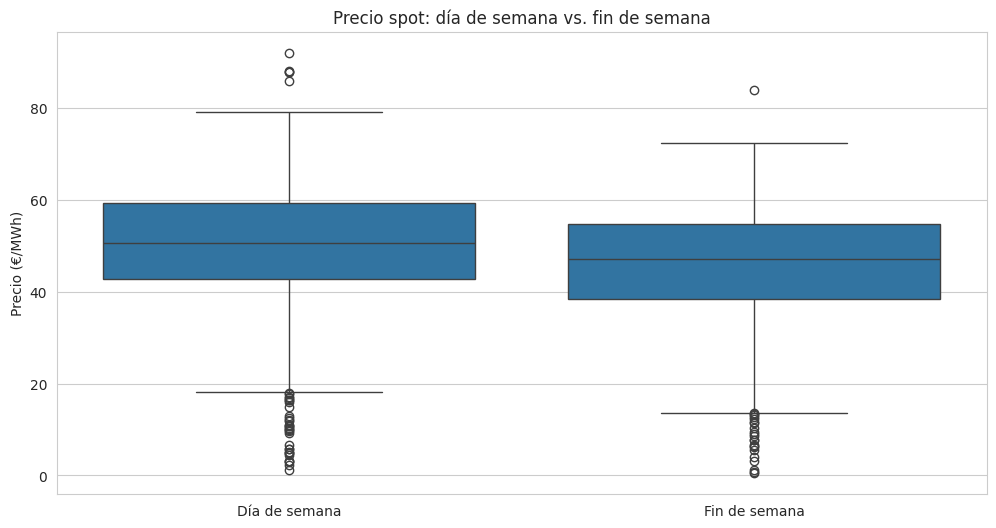

In [20]:
sns.boxplot(x='es_finde', y='precio_eur_mwh', data=serie_es)
plt.title('Precio spot: día de semana vs. fin de semana')
plt.xlabel('')
plt.ylabel('Precio (€/MWh)')
plt.xticks([0, 1], ['Día de semana', 'Fin de semana'])
plt.show()

Mini-reporte de este gráfico:

Hallazgo: el fin de semana muestra una mediana y un rango de precios levemente más bajos que los días de semana (~$47 vs ~$50). La diferencia es real pero moderada.
Recomendación: el tipo de día explica parte de la variación del precio, pero no es el factor dominante — hace falta cuantificar formalmente qué tan fuerte es la relación entre demanda y precio (con una correlación).

### Pairplot: precio y demanda

Esta grilla combina, en una sola imagen, un gráfico de dispersión (scatterplot) entre 
precio y demanda —cada punto es un día— y en la diagonal, la forma de la distribución 
de cada variable sola. Permite ver de un vistazo si ambas variables suben juntas, 
bajan juntas, o no muestran relación clara.

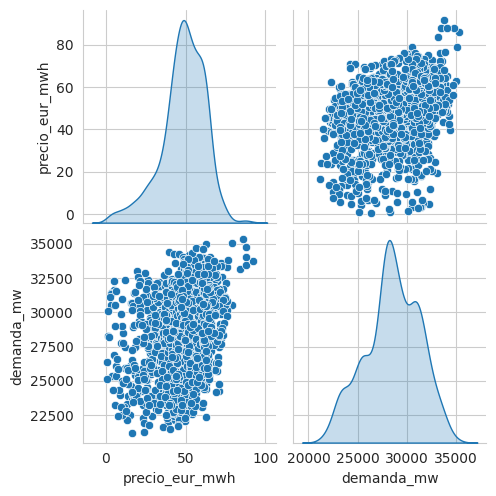

In [21]:
subset = serie_es[['precio_eur_mwh', 'demanda_mw']]

sns.pairplot(subset, diag_kind='kde')
plt.show()

Mini-reporte de este pairplot:

Hallazgo: se confirma visualmente la correlación débil-moderada (0.31) calculada antes — la nube de puntos muestra una tendencia leve hacia arriba, pero con dispersión considerable, muy distinta a una relación fuerte y ordenada.

## Análisis de series temporales

A diferencia del dataset de California Housing, acá cada registro tiene una fecha 
asociada, lo que permite ver cómo evoluciona el precio y la demanda a lo largo del 
tiempo, y detectar patrones que se repiten (por ejemplo, estacionalidad anual).

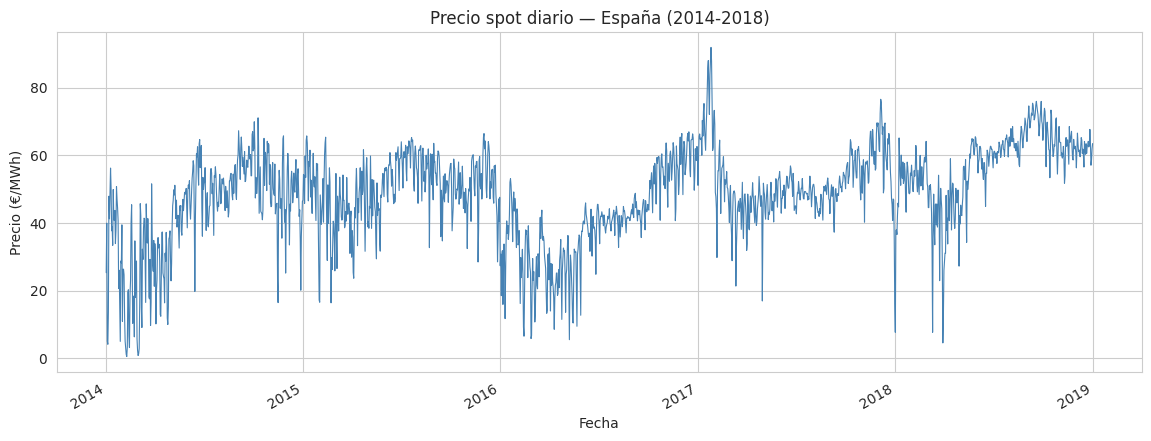

In [22]:
plt.figure(figsize=(14, 5))
serie_es['precio_eur_mwh'].plot(color='steelblue', linewidth=0.8)
plt.title('Precio spot diario — España (2014-2018)')
plt.xlabel('Fecha')
plt.ylabel('Precio (€/MWh)')
plt.show()

Mini-reporte de este gráfico de evolución:

Hallazgo: se identifican al menos 3 valles de precios bajos (inicios de 2014, 2016, y en menor medida 2018), no un episodio único como se pensaba al principio del notebook. También se observa una tendencia de crecimiento del nivel general de precios a lo largo del período, y un pico marcado a inicios de 2017.

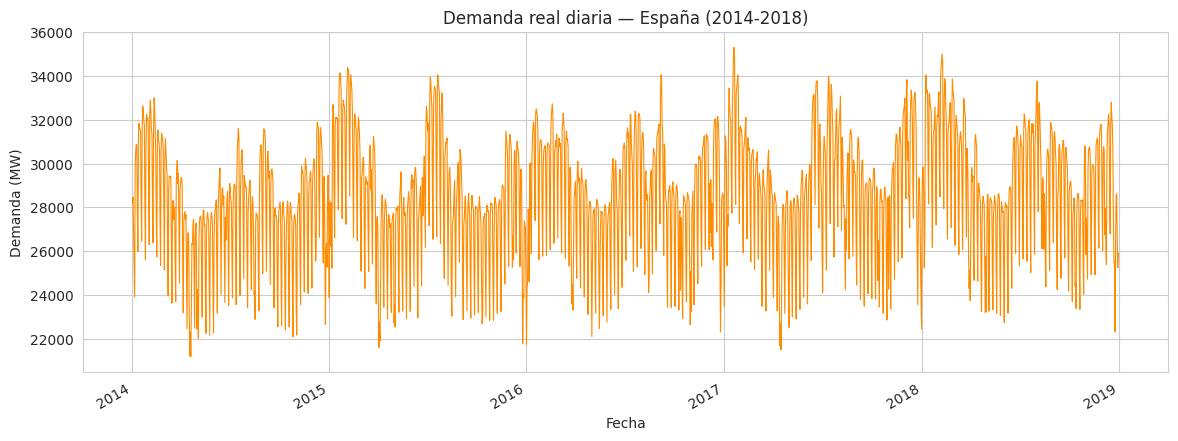

In [23]:
plt.figure(figsize=(14, 5))
serie_es['demanda_mw'].plot(color='darkorange', linewidth=0.8)
plt.title('Demanda real diaria — España (2014-2018)')
plt.xlabel('Fecha')
plt.ylabel('Demanda (MW)')
plt.show()

## Conclusiones

- **La demanda influye en el precio, pero de forma débil** (correlación 0.31) — mucho 
  más débil que la relación ingreso-precio que encontramos en el dataset de Housing.
- **La generación total tampoco explica el precio de forma general** (correlación 0.12, 
  prácticamente nula) — aunque los 10 días de precio más bajo de la serie sí mostraban 
  generación por encima del promedio, ese patrón puntual no se sostiene al mirar la 
  serie completa.
- **El tipo de día también influye, moderadamente:** el precio en fin de semana tiende 
  a ser algo más bajo que en días laborales, consistente con menor actividad económica.
- **El precio muestra valles recurrentes** (inicios de 2014, 2016 y en menor medida 
  2018) y una tendencia de crecimiento general a lo largo del período — un 
  comportamiento mucho más irregular que el de la demanda, que sigue un patrón 
  estacional estable y repetitivo año a año.
- **Ni la demanda ni la generación total explican por sí solas el comportamiento del 
  precio:** se investigaron ambas hipótesis con evidencia real (no solo suposición), y 
  ninguna alcanza para explicar las variaciones de forma consistente — es probable que 
  el precio dependa de una combinación más fina de factores (qué tecnología específica 
  genera, el momento exacto del día, condiciones puntuales del mercado) que este 
  análisis no llega a capturar.

**Conclusión:** En el mercado eléctrico español ninguna de las variables analizadas (demanda, generación total, tipo de día) explica el precio de forma dominante — el mercado eléctrico parece depender de una combinación de 
factores más compleja que lo que este análisis, acotado a precio/demanda/generación 
total, permite capturar completamente.

**Sobre la búsqueda de energía barata:** según lo encontrado, los momentos más 
favorables observados históricamente para precios bajos fueron los fines de semana 
(precio algo más bajo, de forma consistente) y ciertos períodos puntuales como 
inicios de 2014 y 2016 — aunque, como ni la demanda ni la generación total explican 
esos valles de forma confiable, no es posible predecir con seguridad cuándo se 
repetirá un valle futuro.